In [ ]:
pip install torch_geometric torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cpu.html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 545.2/545.2 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 45.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.1/781.1 kB 14.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.3/241.3 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.5 MB/s eta 0:00:00


In [ ]:
pip install torch-scatter -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


In [ ]:
pip install torch-sparse -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


In [ ]:
pip install torch-cluster -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


In [ ]:
pip install torch-geometric

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import libraries
import os
import pandas as pd
import numpy as np

# Step 3: Define base path and folders
base_path = '/content/drive/MyDrive/Projects'
folders = ['Alzheimers_PLV_CSV_theta_only', 'Fronto_PLV_CSV_theta_only', 'Healthy_PLV_CSV_theta_only']
label_map = {
    'Alzheimers_PLV_CSV_theta_only': 'A',
    'Fronto_PLV_CSV_theta_only': 'F',
    'Healthy_PLV_CSV_theta_only': 'H'
}

# Step 4: Count files in each folder and determine the minimum count
file_counts = {folder: len([f for f in os.listdir(os.path.join(base_path, folder)) if f.endswith('.csv')]) for folder in folders}
min_count = min(file_counts.values())

print("Files per class:", file_counts)
print("Using", min_count, "files per class to balance the dataset.")

# Step 5: Load and flatten data
all_samples = []
row_labels = []

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    files = sorted([f for f in os.listdir(folder_path) if f.endswith('.csv')])[:min_count]

    for file_name in files:
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)
        flat_vector = df.values.flatten()
        all_samples.append(flat_vector)
        row_labels.append(label_map[folder])  # Append class label

# Step 6: Create DataFrame
column_names = [f'R{i+1}' for i in range(len(all_samples[0]))]
df_combined = pd.DataFrame(all_samples, columns=column_names)
df_combined.insert(0, 'Class', row_labels)  # Add class label as first column

# Step 7: Remove columns (excluding 'Class') where all values are 1
df_features_only = df_combined.drop(columns='Class')  # Drop class column temporarily
cols_to_remove = df_features_only.columns[(df_features_only == 1).all(axis=0)]  # Identify columns with all 1s
df_combined.drop(columns=cols_to_remove, inplace=True)  # Remove from original DataFrame

# Step 8: Save to Excel
output_file_path = os.path.join(base_path, 'Combined_PLV_Data.xlsx')
df_combined.to_excel(output_file_path, index=False)

print("✅ Removed constant-1 columns:", list(cols_to_remove))
print("✅ Excel file saved to:", output_file_path)
print("✅ Final shape:", df_combined.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files per class: {'Alzheimers_PLV_CSV_theta_only': 469, 'Fronto_PLV_CSV_theta_only': 264, 'Healthy_PLV_CSV_theta_only': 388}
Using 264 files per class to balance the dataset.
✅ Removed constant-1 columns: ['R1', 'R3', 'R6', 'R10', 'R15', 'R21', 'R28', 'R36', 'R45', 'R55', 'R66', 'R78', 'R91', 'R105', 'R120', 'R136', 'R153', 'R171', 'R190', 'R210', 'R231', 'R253', 'R276', 'R300', 'R325', 'R351', 'R378', 'R406', 'R435', 'R465', 'R496', 'R528', 'R561', 'R595', 'R630', 'R666', 'R703', 'R741', 'R780', 'R820', 'R861', 'R903', 'R946', 'R990', 'R1035', 'R1081', 'R1128', 'R1176', 'R1225', 'R1275', 'R1326', 'R1378', 'R1431', 'R1485', 'R1540', 'R1596', 'R1653', 'R1711', 'R1770', 'R1830', 'R1891', 'R1953', 'R2016', 'R2080', 'R2145', 'R2211', 'R2278', 'R2346']
✅ Excel file saved to: /content/drive/MyDrive/Projects/Combined_PLV_Data.xlsx
✅ Final shape: (792, 2279)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


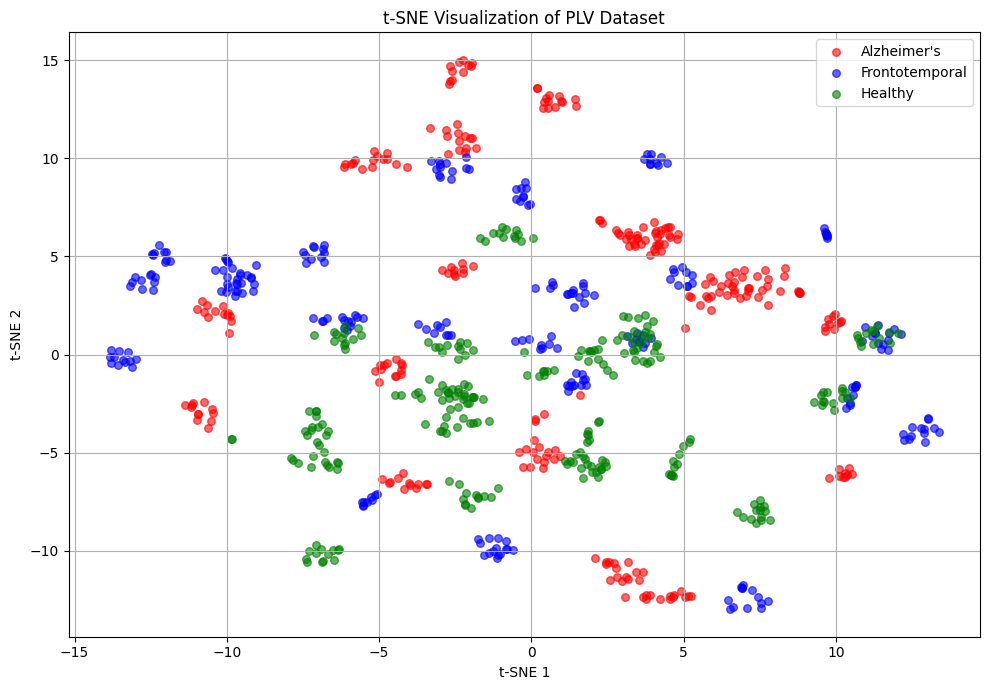

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Step 3: Load dataset
file_path = '/content/drive/MyDrive/Projects/Combined_PLV_Data.xlsx'
df = pd.read_excel(file_path)

# Step 4: Separate features and labels
labels = df['Class'].values
features = df.drop(columns=['Class']).values

# Step 5: Standardize features (very important for t-SNE)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Step 6: Apply t-SNE
tsne = TSNE(n_components=3, perplexity=30, random_state=42, n_iter=1000)
tsne_results = tsne.fit_transform(features_scaled)

# Step 7: Visualize
plt.figure(figsize=(10, 7))
label_map = {'A': 'Alzheimer\'s', 'F': 'Frontotemporal', 'H': 'Healthy'}
colors = {'A': 'red', 'F': 'blue', 'H': 'green'}

for label in np.unique(labels):
    idx = labels == label
    plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1],
                label=label_map[label], c=colors[label], alpha=0.6, s=30)

plt.title("t-SNE Visualization of PLV Dataset")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📂 Fold 1/5
⏹️ Early stopping at epoch 30
✅ Fold 1 Accuracy: 0.8239
[[45  1  7]
 [ 9 33 11]
 [ 0  0 53]]

📂 Fold 2/5
⏹️ Early stopping at epoch 24
✅ Fold 2 Accuracy: 0.7610
[[31 13  9]
 [ 6 37 10]
 [ 0  0 53]]

📂 Fold 3/5
⏹️ Early stopping at epoch 24
✅ Fold 3 Accuracy: 0.8418
[[53  0  0]
 [13 29 11]
 [ 1  0 51]]

📂 Fold 4/5
⏹️ Early stopping at epoch 23
✅ Fold 4 Accuracy: 0.8354
[[45  0  8]
 [ 6 34 12]
 [ 0  0 53]]

📂 Fold 5/5
⏹️ Early stopping at epoch 24
✅ Fold 5 Accuracy: 0.8481
[[29 23  0]
 [ 1 52  0]
 [ 0  0 53]]

🏁 Average Accuracy over 5 folds: 0.8220


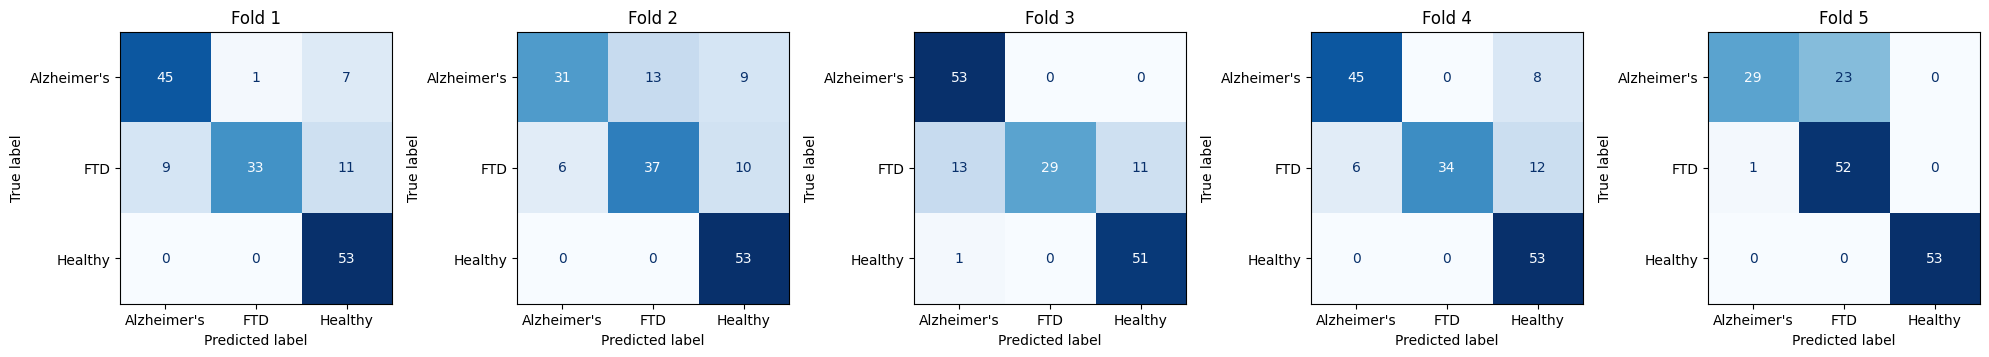

In [ ]:
# --- Step 1: Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Step 2: Import libraries ---
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import NearestNeighbors
from torch_geometric.nn import GATConv
from torch_geometric.data import Data

# --- Step 3: Device setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Step 4: Load data ---
file_path = '/content/drive/MyDrive/Projects/Combined_PLV_Data.xlsx'
df = pd.read_excel(file_path)

# Map class labels to integers
label_mapping = {'A': 0, 'F': 1, 'H': 2}
y = df['Class'].map(label_mapping).values
X = df.drop(columns=['Class']).values

# --- Step 5: Normalize Features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(X_scaled, dtype=torch.float)
y_tensor = torch.tensor(y, dtype=torch.long)

# --- Step 6: Build Mutual k-NN Graph (k=2) using Cosine Similarity ---
k = 2
nbrs = NearestNeighbors(n_neighbors=k + 1, metric='cosine').fit(X_scaled)
_, knn_indices = nbrs.kneighbors(X_scaled)

mutual_edges = set()
for i, neighbors in enumerate(knn_indices):
    for j in neighbors[1:]:  # skip self
        if i in knn_indices[j][1:]:
            mutual_edges.add((i, j))
            mutual_edges.add((j, i))

edge_index = torch.tensor(list(mutual_edges), dtype=torch.long).t().contiguous()

# --- Step 7: GAT Model ---
class GAT(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, heads=8, feat_dropout=0.2):
        super(GAT, self).__init__()
        self.gat1 = GATConv(input_dim, hidden_dim, heads=heads, dropout=0.6)
        self.gat2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, dropout=0.6)
        self.out = nn.Linear(hidden_dim, output_dim)
        self.feat_dropout = feat_dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        if self.training:
            x = F.dropout(x, p=self.feat_dropout)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.gat2(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        return self.out(x)

# --- Step 8: Compute Class Weights ---
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

# --- Step 9: Cross Validation and Training ---
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
accuracies = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y)):
    print(f"\n📂 Fold {fold + 1}/{k_folds}")

    train_mask = torch.zeros(X_scaled.shape[0], dtype=torch.bool)
    test_mask = torch.zeros(X_scaled.shape[0], dtype=torch.bool)
    train_mask[train_idx] = True
    test_mask[test_idx] = True

    data = Data(x=X_tensor, edge_index=edge_index, y=y_tensor,
                train_mask=train_mask, test_mask=test_mask).to(device)

    model = GAT(input_dim=X_scaled.shape[1], hidden_dim=64, output_dim=3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

    best_acc = 0
    best_model = None
    patience, wait = 10, 0

    for epoch in range(1, 201):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        scheduler.step()

        # Early stopping
        model.eval()
        with torch.no_grad():
            preds = model(data).argmax(dim=1)
            acc = accuracy_score(data.y[data.test_mask].cpu(), preds[data.test_mask].cpu())

            if acc > best_acc:
                best_acc = acc
                best_model = model.state_dict()
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"⏹️ Early stopping at epoch {epoch}")
                    break

    # Evaluate best model
    model.load_state_dict(best_model)
    model.eval()
    with torch.no_grad():
        preds = model(data).argmax(dim=1)
        acc = accuracy_score(data.y[data.test_mask].cpu(), preds[data.test_mask].cpu())
        cm = confusion_matrix(data.y[data.test_mask].cpu(), preds[data.test_mask].cpu())
        accuracies.append(acc)
        conf_matrices.append(cm)

        print(f"✅ Fold {fold + 1} Accuracy: {acc:.4f}")
        print(cm)

# --- Step 10: Final Results ---
print(f"\n🏁 Average Accuracy over {k_folds} folds: {np.mean(accuracies):.4f}")

# --- Step 11: Plot Confusion Matrices ---
fig, axes = plt.subplots(1, k_folds, figsize=(20, 4))
class_names = ["Alzheimer's", "FTD", "Healthy"]

for i, cm in enumerate(conf_matrices):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[i], cmap=plt.cm.Blues, values_format='d', colorbar=False)
    axes[i].set_title(f"Fold {i+1}")
    axes[i].grid(False)

plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📂 Fold 1/5
⏹️ Early stopping at epoch 27
✅ Fold 1 Accuracy: 0.9497
[[50  1  2]
 [ 0 48  5]
 [ 0  0 53]]

📂 Fold 2/5
⏹️ Early stopping at epoch 40
✅ Fold 2 Accuracy: 1.0000
[[53  0  0]
 [ 0 53  0]
 [ 0  0 53]]

📂 Fold 3/5
⏹️ Early stopping at epoch 34
✅ Fold 3 Accuracy: 1.0000
[[53  0  0]
 [ 0 53  0]
 [ 0  0 52]]

📂 Fold 4/5
⏹️ Early stopping at epoch 30
✅ Fold 4 Accuracy: 0.9873
[[52  0  1]
 [ 0 52  0]
 [ 1  0 52]]

📂 Fold 5/5
⏹️ Early stopping at epoch 31
✅ Fold 5 Accuracy: 1.0000
[[52  0  0]
 [ 0 53  0]
 [ 0  0 53]]

🏁 Average Accuracy over 5 folds: 0.9874


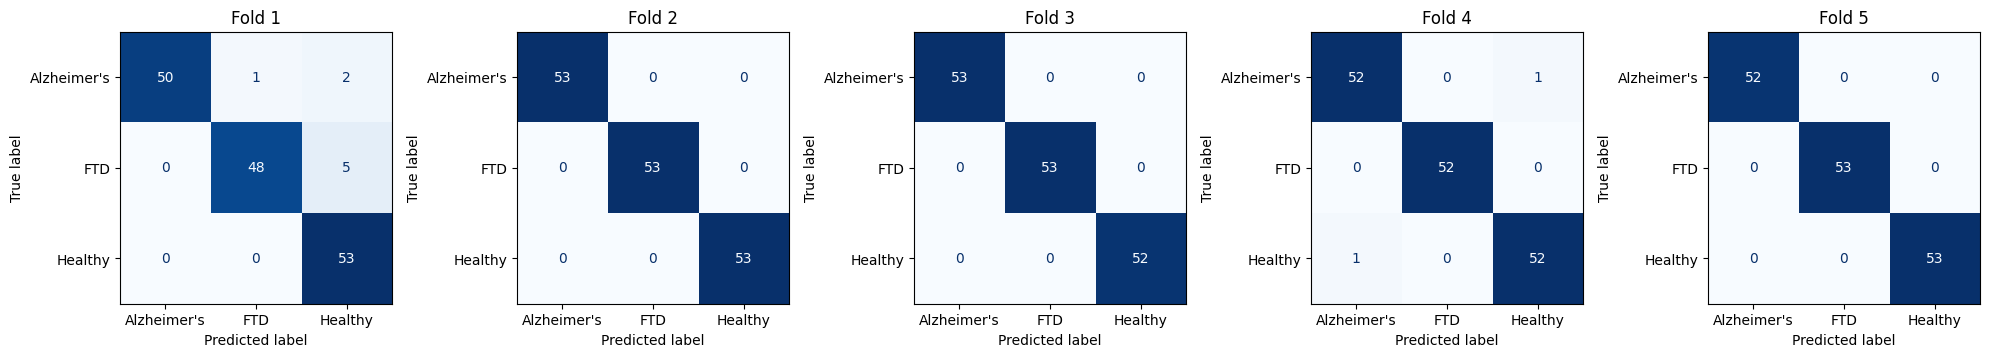

In [ ]:
# --- Step 1: Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Step 2: Import libraries ---
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import NearestNeighbors
from torch_geometric.nn import GATConv
from torch_geometric.data import Data

# --- Step 3: Device setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Step 4: Load data ---
file_path = '/content/drive/MyDrive/Projects/Combined_PLV_Data.xlsx'
df = pd.read_excel(file_path)

label_mapping = {'A': 0, 'F': 1, 'H': 2}
y = df['Class'].map(label_mapping).values
X = df.drop(columns=['Class']).values

# --- Step 5: Normalize Features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_tensor = torch.tensor(X_scaled, dtype=torch.float)
y_tensor = torch.tensor(y, dtype=torch.long)

# --- Step 6: Build Mutual k-NN Graph ---
k = 2
nbrs = NearestNeighbors(n_neighbors=k + 1, metric='cosine').fit(X_scaled)
_, knn_indices = nbrs.kneighbors(X_scaled)

mutual_edges = set()
for i, neighbors in enumerate(knn_indices):
    for j in neighbors[1:]:
        if i in knn_indices[j][1:]:
            mutual_edges.add((i, j))
            mutual_edges.add((j, i))
edge_index = torch.tensor(list(mutual_edges), dtype=torch.long).t().contiguous()

# --- Step 7: Improved GAT Model ---
class GAT(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, heads=8, feat_dropout=0.2):
        super(GAT, self).__init__()
        self.bn1 = nn.BatchNorm1d(input_dim)
        self.gat1 = GATConv(input_dim, hidden_dim, heads=heads, dropout=0.6)
        self.gat2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, dropout=0.6)
        self.out = nn.Linear(hidden_dim, output_dim)
        self.feat_dropout = feat_dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.bn1(x)
        x = F.dropout(x, p=self.feat_dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.gat2(x, edge_index)
        x = F.elu(x)
        x = self.out(x)
        return x

# --- Step 8: Class Weights ---
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

# --- Step 9: Cross Validation and Training ---
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
accuracies = []
conf_matrices = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y)):
    print(f"\n📂 Fold {fold + 1}/{k_folds}")

    train_mask = torch.zeros(X_scaled.shape[0], dtype=torch.bool)
    test_mask = torch.zeros(X_scaled.shape[0], dtype=torch.bool)
    train_mask[train_idx] = True
    test_mask[test_idx] = True

    data = Data(x=X_tensor, edge_index=edge_index, y=y_tensor,
                train_mask=train_mask, test_mask=test_mask).to(device)

    model = GAT(input_dim=X_scaled.shape[1], hidden_dim=64, output_dim=3).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

    best_acc = 0
    best_model = None
    patience, wait = 15, 0

    for epoch in range(1, 301):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            preds = model(data).argmax(dim=1)
            acc = accuracy_score(data.y[data.test_mask].cpu(), preds[data.test_mask].cpu())
            scheduler.step(acc)

            if acc > best_acc:
                best_acc = acc
                best_model = model.state_dict()
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"⏹️ Early stopping at epoch {epoch}")
                    break

    # Evaluate best model
    model.load_state_dict(best_model)
    model.eval()
    with torch.no_grad():
        preds = model(data).argmax(dim=1)
        acc = accuracy_score(data.y[data.test_mask].cpu(), preds[data.test_mask].cpu())
        cm = confusion_matrix(data.y[data.test_mask].cpu(), preds[data.test_mask].cpu())
        accuracies.append(acc)
        conf_matrices.append(cm)

        print(f"✅ Fold {fold + 1} Accuracy: {acc:.4f}")
        print(cm)

# --- Step 10: Final Results ---
print(f"\n🏁 Average Accuracy over {k_folds} folds: {np.mean(accuracies):.4f}")

# --- Step 11: Plot Confusion Matrices ---
fig, axes = plt.subplots(1, k_folds, figsize=(20, 4))
class_names = ["Alzheimer's", "FTD", "Healthy"]

for i, cm in enumerate(conf_matrices):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[i], cmap=plt.cm.Blues, values_format='d', colorbar=False)
    axes[i].set_title(f"Fold {i+1}")
    axes[i].grid(False)

plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🔵 Evaluating k = 1
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5
✅ Average Accuracy for k=1: 0.9785

🔵 Evaluating k = 2
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5
✅ Average Accuracy for k=2: 0.9722

🔵 Evaluating k = 3
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5
✅ Average Accuracy for k=3: 0.9798

🔵 Evaluating k = 4
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5
✅ Average Accuracy for k=4: 0.9722

🔵 Evaluating k = 5
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5
✅ Average Accuracy for k=5: 0.9773

🔵 Evaluating k = 6
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5
✅ Average Accuracy for k=6: 0.9798

🔵 Evaluating k = 7
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5
✅ Average Accuracy for k=7: 0.9583

🔵 Evaluating k = 8
 Fold 1/5
 Fold 2/5
 Fold 3/5
 Fold 4/5
 Fold 5/5
✅ Average Accuracy for k=8: 0.9520

🔵 Evaluating k = 9
 Fold 1/5
 

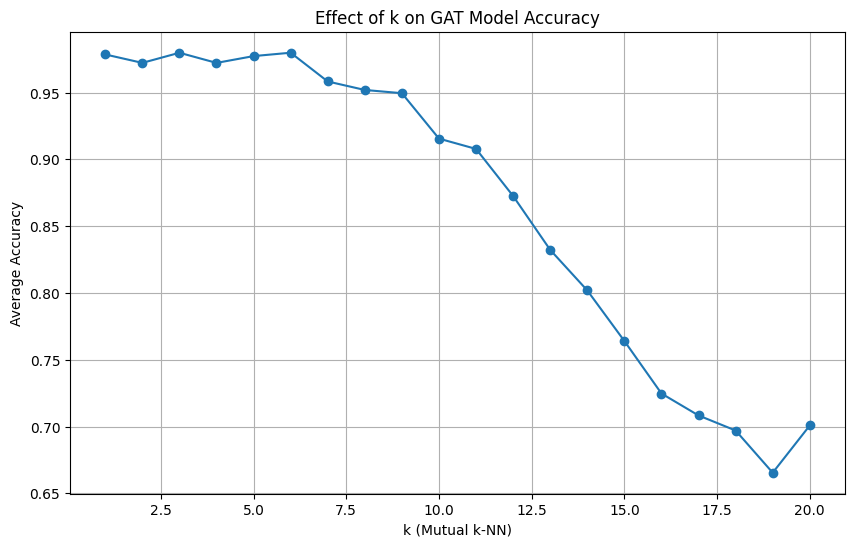

In [ ]:
# --- Step 1: Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Step 2: Import libraries ---
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import NearestNeighbors
from torch_geometric.nn import GATConv
from torch_geometric.data import Data

# --- Step 3: Device setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Step 4: Load data ---
file_path = '/content/drive/MyDrive/Projects/Combined_PLV_Data.xlsx'
df = pd.read_excel(file_path)

label_mapping = {'A': 0, 'F': 1, 'H': 2}
y = df['Class'].map(label_mapping).values
X = df.drop(columns=['Class']).values

# --- Step 5: Normalize Features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_tensor = torch.tensor(X_scaled, dtype=torch.float)
y_tensor = torch.tensor(y, dtype=torch.long)

# --- Step 6: Compute Class Weights ---
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

# --- Step 7: GAT Model ---
class GAT(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, heads=8, feat_dropout=0.2):
        super(GAT, self).__init__()
        self.gat1 = GATConv(input_dim, hidden_dim, heads=heads, dropout=0.6)
        self.gat2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, dropout=0.6)
        self.out = nn.Linear(hidden_dim, output_dim)
        self.feat_dropout = feat_dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.dropout(x, p=self.feat_dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.gat2(x, edge_index)
        x = F.elu(x)
        x = self.out(x)
        return x

# --- Step 8: Loop over k and compute accuracies ---
k_values = range(1, 21)
k_accuracies = []

for k in k_values:
    print(f"\n===============================")
    print(f"🔵 Evaluating k = {k}")

    # --- Build Mutual k-NN Graph ---
    nbrs = NearestNeighbors(n_neighbors=k + 1, metric='cosine').fit(X_scaled)
    _, knn_indices = nbrs.kneighbors(X_scaled)

    mutual_edges = set()
    for i, neighbors in enumerate(knn_indices):
        for j in neighbors[1:]:
            if i in knn_indices[j][1:]:
                mutual_edges.add((i, j))
                mutual_edges.add((j, i))
    edge_index = torch.tensor(list(mutual_edges), dtype=torch.long).t().contiguous()

    # --- Cross-validation setup ---
    k_folds = 5
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    fold_accuracies = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y)):
        print(f" Fold {fold+1}/{k_folds}")

        train_mask = torch.zeros(X_scaled.shape[0], dtype=torch.bool)
        test_mask = torch.zeros(X_scaled.shape[0], dtype=torch.bool)
        train_mask[train_idx] = True
        test_mask[test_idx] = True

        data = Data(
            x=X_tensor,
            edge_index=edge_index,
            y=y_tensor,
            train_mask=train_mask,
            test_mask=test_mask
        ).to(device)

        model = GAT(input_dim=X_scaled.shape[1], hidden_dim=64, output_dim=3).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

        best_acc = 0
        best_model = None
        patience, wait = 10, 0

        for epoch in range(1, 151):
            model.train()
            optimizer.zero_grad()
            out = model(data)
            loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            # Validation
            model.eval()
            with torch.no_grad():
                preds = model(data).argmax(dim=1)
                acc = accuracy_score(data.y[data.test_mask].cpu(), preds[data.test_mask].cpu())

                if acc > best_acc:
                    best_acc = acc
                    best_model = model.state_dict()
                    wait = 0
                else:
                    wait += 1
                    if wait >= patience:
                        break

        # Evaluate best model
        model.load_state_dict(best_model)
        model.eval()
        with torch.no_grad():
            preds = model(data).argmax(dim=1)
            acc = accuracy_score(data.y[data.test_mask].cpu(), preds[data.test_mask].cpu())
            fold_accuracies.append(acc)

    avg_acc = np.mean(fold_accuracies)
    k_accuracies.append(avg_acc)
    print(f"✅ Average Accuracy for k={k}: {avg_acc:.4f}")

# --- Step 9: Plot k vs. Accuracy ---
plt.figure(figsize=(10, 6))
plt.plot(k_values, k_accuracies, marker='o')
plt.xlabel("k (Mutual k-NN)")
plt.ylabel("Average Accuracy")
plt.title("Effect of k on GAT Model Accuracy")
plt.grid(True)
plt.show()
